<a href="https://colab.research.google.com/github/emilsar/Cedars/blob/main/Project3/Pre_1_load_data_operations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Image Basics

###Creating the Image

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import filters, morphology, exposure  # Add this line

# Create 10x10 grayscale image with values [0, 1]
image = np.array([
    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    [1.0, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.4, 0.4, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.0, 0.1, 0.2, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.0, 0.0, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.4, 0.4, 0.3, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.6, 0.6, 0.6, 0.6, 0.5, 0.8, 1.0],
    [1.0, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 1.0],
    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
], dtype=np.float32)

print("Image values (float in [0,1]):")
print(image)
print(f"\nShape: {image.shape}")
print(f"Data Type it Contains: {image.dtype}")
print(f"Type of Object: {type(image)}")
print(f"Range: [{image.min()}, {image.max()}]")

Image values (float in [0,1]):
[[1.  1.  1.  1.  1.  1.  1.  1.  1.  1. ]
 [1.  0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 1. ]
 [1.  0.8 0.6 0.6 0.6 0.6 0.6 0.6 0.8 1. ]
 [1.  0.8 0.6 0.4 0.4 0.4 0.4 0.6 0.8 1. ]
 [1.  0.8 0.6 0.4 0.  0.1 0.2 0.6 0.8 1. ]
 [1.  0.8 0.6 0.4 0.  0.  0.4 0.6 0.8 1. ]
 [1.  0.8 0.6 0.4 0.4 0.4 0.3 0.6 0.8 1. ]
 [1.  0.8 0.6 0.6 0.6 0.6 0.6 0.5 0.8 1. ]
 [1.  0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 1. ]
 [1.  1.  1.  1.  1.  1.  1.  1.  1.  1. ]]

Shape: (10, 10)
Data Type it Contains: float32
Type of Object: <class 'numpy.ndarray'>
Range: [0.0, 1.0]


###Displaying Images and Interpolations

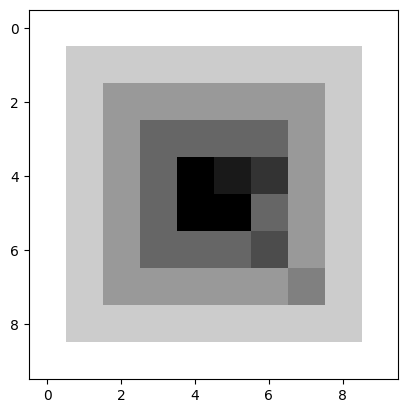

In [ ]:
#plt.figure(figsize=(3, 3))
plt.imshow(image, cmap='gray', interpolation='nearest', vmin=0, vmax=1)
#plt.colorbar(label='Intensity [0,1]')
#plt.title("10x10 Grayscale Image (float [0,1])")
#plt.show()

Here's what you can typically do with the `fig` object:

*   **Set a main title for the entire figure:** `fig.suptitle('Main Title')`
*   **Save the figure to a file:** `fig.savefig('my_plot.png')`
*   **Adjust its size:** `fig.set_size_inches(width, height)` (though often set during `subplots` creation)
*   **Set its background color:** `fig.set_facecolor('lightgray')`
*   **Add overall text or annotations:** `fig.text(x, y, 'Some text')`
*   **Manage its subplots (axes):** While `axes` directly control individual plots, `fig` holds the collection.

Let's demonstrate some of these with an example using your existing image data.

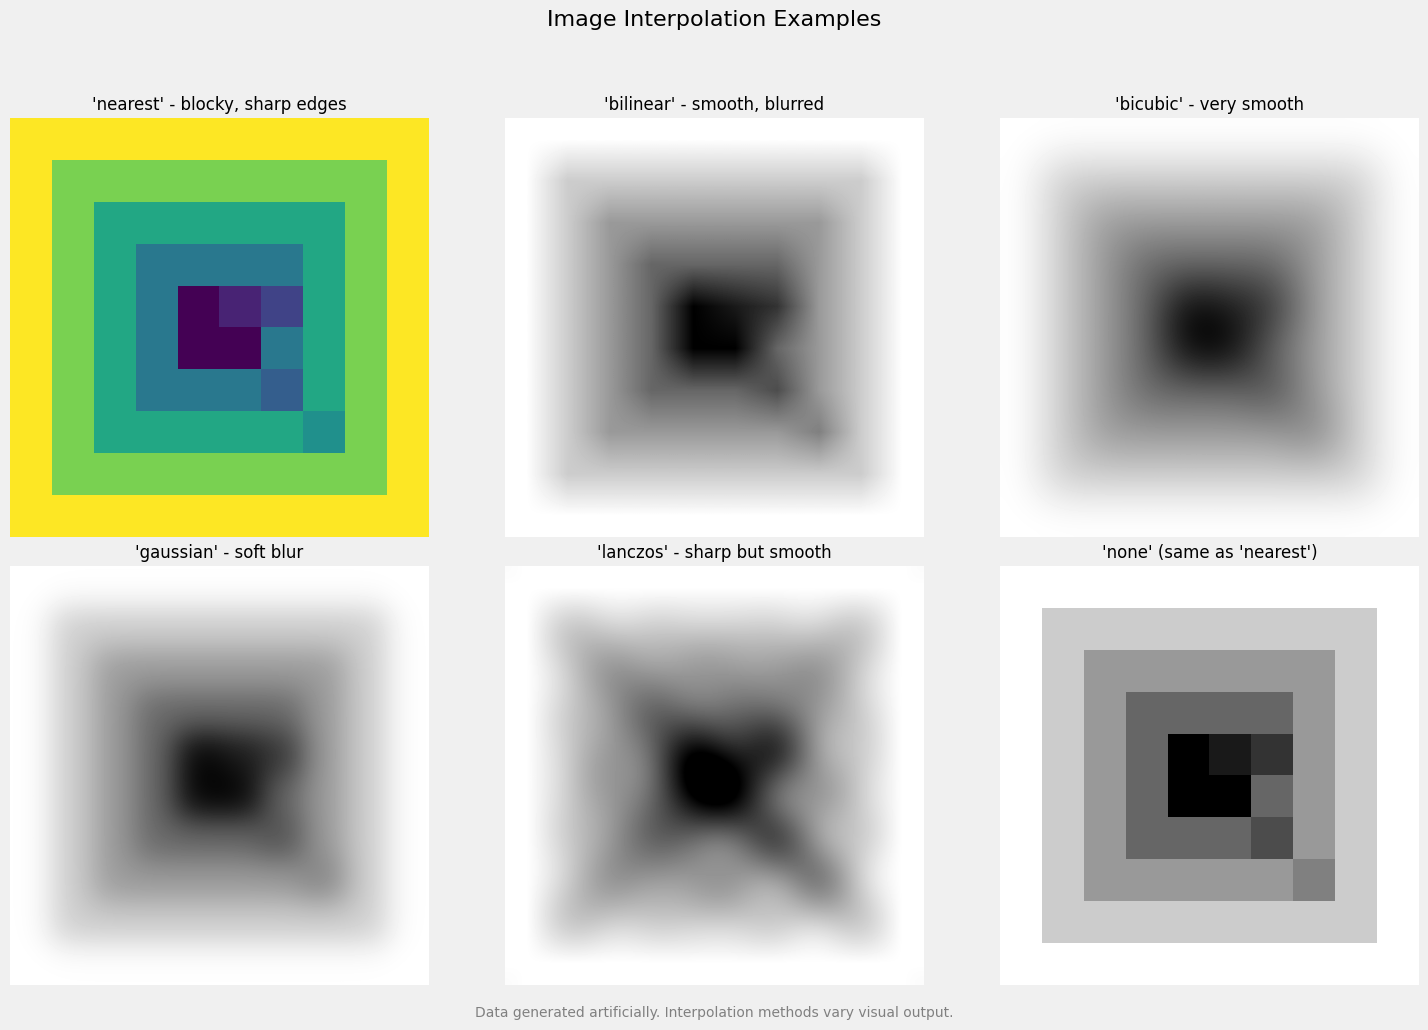

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Re-creating the image variable for context in this cell, if it's not available globally
# This assumes 'image' is the 10x10 numpy array defined earlier.
# If 'image' is already available from previous execution, you can skip this block
image = np.array([
    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    [1.0, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.4, 0.4, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.0, 0.1, 0.2, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.0, 0.0, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.4, 0.4, 0.3, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.6, 0.6, 0.6, 0.6, 0.5, 0.8, 1.0],
    [1.0, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 1.0],
    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
], dtype=np.float32)


fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# --- Operations on the `fig` object ---

# 1. Set a super title for the entire figure
fig.suptitle('Image Interpolation Examples', fontsize=16, y=1.02)

# 2. Set the background color of the figure
fig.set_facecolor('#f0f0f0') # A light gray color

# 3. Add some general text to the figure (e.g., a footnote)
fig.text(0.5, 0.01, 'Data generated artificially. Interpolation methods vary visual output.',
         ha='center', va='bottom', fontsize=10, color='gray')

# --- Now, populate the subplots (axes) as before ---
axes[0, 0].imshow(image, cmap='viridis', interpolation='nearest')
axes[0, 0].set_title("'nearest' - blocky, sharp edges")
axes[0, 0].axis('off')

axes[0, 1].imshow(image, cmap='gray', interpolation='bilinear')
axes[0, 1].set_title("'bilinear' - smooth, blurred")
axes[0, 1].axis('off')

axes[0, 2].imshow(image, cmap='gray', interpolation='bicubic')
axes[0, 2].set_title("'bicubic' - very smooth")
axes[0, 2].axis('off')

axes[1, 0].imshow(image, cmap='gray', interpolation='gaussian')
axes[1, 0].set_title("'gaussian' - soft blur")
axes[1, 0].axis('off')

axes[1, 1].imshow(image, cmap='gray', interpolation='lanczos')
axes[1, 1].set_title("'lanczos' - sharp but smooth")
axes[1, 1].axis('off')

axes[1, 2].imshow(image, cmap='gray', interpolation='none')
axes[1, 2].set_title("'none' (same as 'nearest')")
axes[1, 2].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle and fig.text
plt.show()

# 4. Save the entire figure to a file (uncomment to enable)
# fig.savefig('interpolations_figure.png', dpi=300, bbox_inches='tight')

###Notes on Interpolations & Colormaps

For Bilinear Interpolation See:  https://www.youtube.com/watch?v=AqscP7rc8_M

Matplotlib's `imshow` function supports various interpolation methods, which determine how the image is resized or displayed when the number of pixels in the data doesn't match the number of pixels on the screen. This is especially important for small images, where interpolation can significantly change the visual appearance.

Here are the common interpolation methods:

*   **`none`**: (Also often referred to as 'nearest') No interpolation. Each data point is rendered as a square pixel. This results in a blocky, pixelated look, especially when scaling up. It's often the default or visually equivalent to 'nearest'.

*   **`nearest`**: Each displayed pixel takes the value of the nearest data point. Produces blocky, sharp edges. Good for categorical data or when you want to preserve individual pixel values without blending.

*   **`bilinear`**: Each displayed pixel's value is an average of the four nearest data points, weighted by distance. This results in a smoother, slightly blurred appearance compared to 'nearest'. Good for continuous data.

*   **`bicubic`**: Similar to bilinear but considers 16 nearest data points, using cubic spline interpolation. Produces a very smooth, often visually pleasing result, but can sometimes introduce artifacts or overshoot pixel values.

*   **`spline16`**: 16-point spline interpolation.

*   **`spline36`**: 36-point spline interpolation.

*   **`hanning`**: Hanning window interpolation.

*   **`hamming`**: Hamming window interpolation.

*   **`hermite`**: Hermite interpolation.

*   **`kaiser`**: Kaiser window interpolation.

*   **`quadric`**: Quadratic interpolation.

*   **`catrom`**: Catmull-Rom spline interpolation.

*   **`gaussian`**: Gaussian filter interpolation. Applies a Gaussian blur, resulting in a soft, smooth appearance.

*   **`bessel`**: Bessel function interpolation.

*   **`mitchell`**: Mitchell-Netravali interpolation.

*   **`sinc`**: Sinc interpolation.

*   **`lanczos`**: Lanczos sampling. A high-quality interpolation often used for downscaling images, providing a good balance between sharpness and artifact reduction. It can appear sharp but smooth.

*   **`blackman`**: Blackman window interpolation.

For most general image display, `nearest`, `bilinear`, `bicubic`, and `lanczos` are the most commonly used and visually distinct options. The best choice often depends on the specific data and the desired visual effect.

Matplotlib provides many built-in colormaps, categorized as follows:

*   **Perceptually Uniform Sequential:** These colormaps are designed to have an evenly changing luminance (brightness) throughout their range. They are good for representing data where continuity and order are important.
    *   `viridis`, `plasma`, `inferno`, `magma`, `cividis`, `twilight`, `twilight_shifted`, `turbo`

*   **Sequential:** These colormaps are also for ordered data, often representing quantities from low to high. They may not be perceptually uniform.
    *   `Greys`, `Purples`, `Blues`, `Greens`, `Oranges`, `Reds`
    *   `YlOrBr`, `YlOrRd`, `OrRd`, `PuBuGn`, `PuBu`, `GnBu`, `BuGn`, `YlGnBu`, `YlGn`

*   **Sequential (2):** Another set of sequential colormaps, often with a slightly different aesthetic.
    *   `binary`, `gist_yarg`, `gist_gray`, `gray`, `bone`, `pink`, `spring`, `summer`, `autumn`, `winter`, `cool`, `Wistia`, `hot`, `afmhot`, `gist_heat`, `copper`

*   **Diverging:** These colormaps are used when data has a meaningful mid-point (e.g., zero) and diverges in two directions (e.g., positive/negative, above/below average).
    *   `PiYG`, `PRGn`, `BrBG`, `PuOr`, `RdGy`, `RdBu`, `RdYlBu`, `RdYlGn`, `Spectral`, `coolwarm`, `bwr`, `seismic`

*   **Cyclic:** These colormaps are for data that wraps around, like phase angles or directions.
    *   `twilight`, `twilight_shifted`, `hsv`

*   **Qualitative:** Used for discrete categories, where no ordering or relationship between categories is implied.
    *   `Pastel1`, `Pastel2`, `Paired`, `Accent`, `Dark2`, `Set1`, `Set2`, `Set3`, `tab10`, `tab20`, `tab20b`, `tab20c`

*   **Miscellaneous:** Other colormaps that don't fit neatly into the above categories.
    *   `flag`, `prism`, `ocean`, `gist_earth`, `terrain`, `gist_stern`, `gnuplot`, `gnuplot2`, `CMRmap`, `cubehelix`, `brg`, `gist_rainbow`, `rainbow`, `jet`, `nipy_spectral`, `gist_ncar`

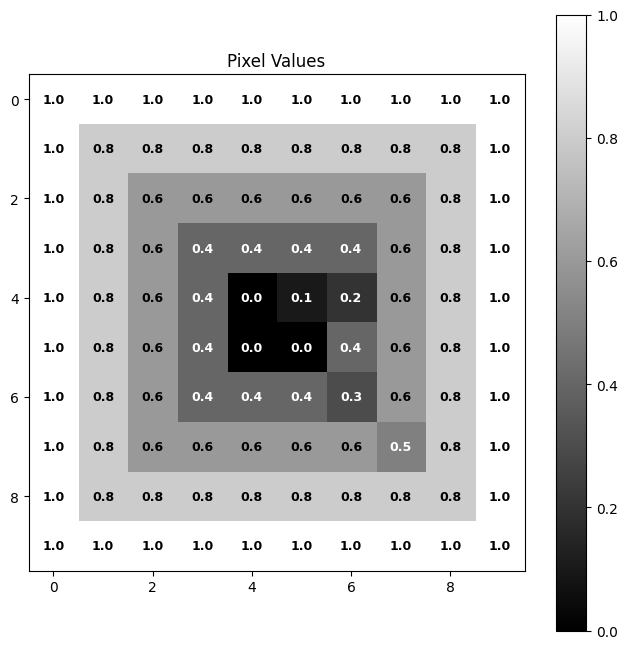

In [ ]:
# Display with numerical values
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image, cmap='gray', interpolation='nearest', vmin=0, vmax=1)
for i in range(10):
    for j in range(10):
        color = "black" if image[i, j] > 0.5 else "white"
        ax.text(j, i, f'{image[i, j]:.1f}',
               ha="center", va="center",
               color=color, fontsize=9, weight='bold')
ax.set_title("Pixel Values")
plt.colorbar(ax.imshow(image, cmap='gray', interpolation='nearest', vmin=0, vmax=1))
plt.show()

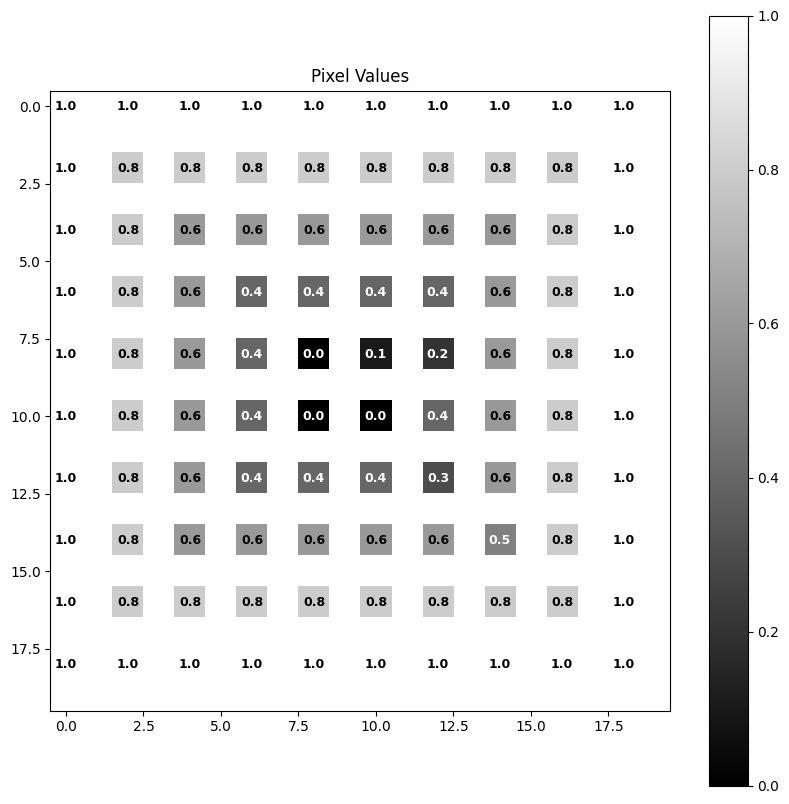

In [ ]:
# Create 20x20 sparse grid
scale_factor = 2
sparse = np.full((20, 20), np.nan, dtype=np.float32)

for i in range(10):
    for j in range(10):
        sparse[i*scale_factor, j*scale_factor] = image[i, j]

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(sparse, cmap='gray', vmin=0, vmax=1, interpolation='nearest')

for i in range(10):
    for j in range(10):
        value = image[i, j]
        color = "black" if value > 0.5 else "white"
        pos_i = i * scale_factor
        pos_j = j * scale_factor
        ax.text(pos_j, pos_i, f'{value:.1f}',
               ha="center", va="center",
               color=color, fontsize=9, weight='bold')

ax.set_title("Pixel Values")
plt.colorbar(ax.images[0], ax=ax)
plt.show()

###Image Statistics

In [ ]:
print (image[:][2])
print (np.mean(image[:][2]))

[1.  0.8 0.6 0.6 0.6 0.6 0.6 0.6 0.8 1. ]
0.72


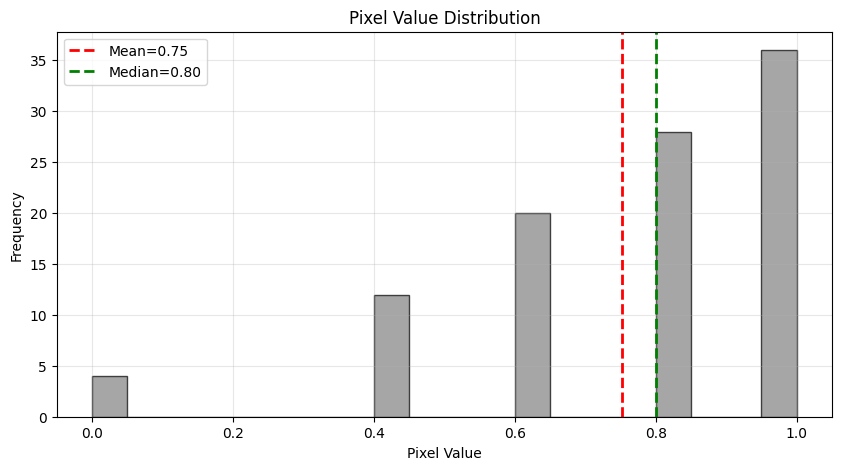

In [ ]:
# Histogram
plt.figure(figsize=(10, 5))
plt.hist(image.flatten(), bins=20, color='gray', alpha=0.7, edgecolor='black')
plt.axvline(image.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean={image.mean():.2f}')
plt.axvline(np.median(image), color='g', linestyle='--', linewidth=2, label=f'Median={np.median(image):.2f}')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Pixel Value Distribution')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

###Committing to Github

In [ ]:
!git clone https://emilsar:@github.com/emilsar/Cedars.git


Cloning into 'Cedars'...
remote: Enumerating objects: 1133, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 1133 (delta 22), reused 4 (delta 0), pack-reused 1088 (from 2)
Receiving objects: 100% (1133/1133), 1.22 GiB | 29.90 MiB/s, done.
Resolving deltas: 100% (399/399), done.
Updating files: 100% (893/893), done.


In [ ]:
%cd Cedars/Project3/
%ls

/content/Cedars/Project3
 0_package_installs.ipynb        final_thresholds.pkl
 1_load_data_operations.ipynb    imagedata/
 1_prepdata.py                   Project3_Description.md
 2_Intensity_Approach.ipynb      __pycache__/
 3_Feature_Extraction.ipynb      QuPath_Examples/
 4_KMeans_RF.ipynb               QuPath_Examples.zip
 5_DL_image_segmentation.ipynb  'SAM protocol.docx'
 cell_images/                    seg_models/
 deprecated/                     semseg_functions.py
 DL_result_imgs/                 specimens_toy_data.pkl
 feature_extraction_utils.py


In [ ]:
np.save("artificial_cell",image)
!git add artificial_cell.npy
!git commit -m "Add cell image"
# Update the remote URL to include your token
#!git remote set-url origin https://emilsar@github.com/emilsar/Cedars.git
!git config --global user.email "emilsar@github.com"
!git config --global user.name "emilsar"

# Now regular push works
!git push

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 456 bytes | 456.00 KiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/emilsar/Cedars.git
   42e356f..beaaa9c  main -> main


#Noise and Noise Reduction

##Creating Noise

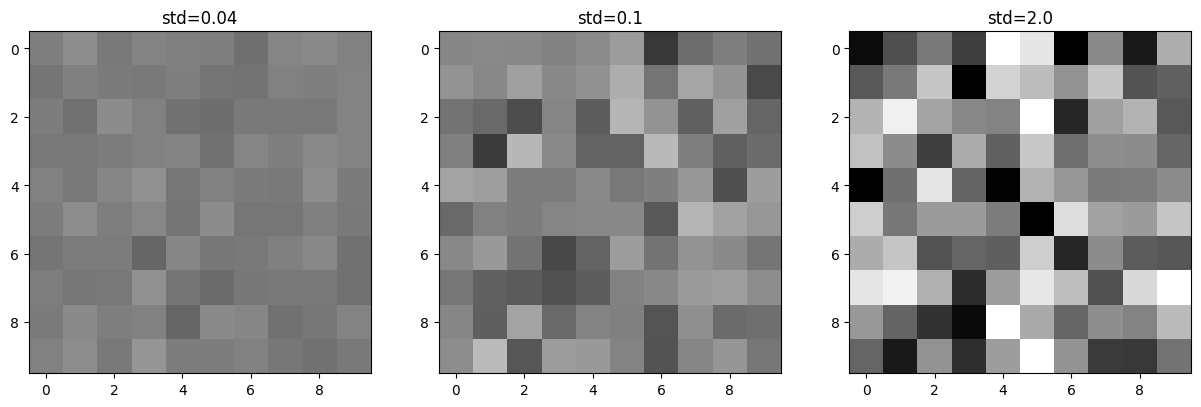

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

noise1 = np.random.normal(0, 0.04,image.shape)
noise2 = np.random.normal(0, 0.1, image.shape)
noise3 = np.random.normal(0, 0.3, image.shape)

axes[0].imshow(noise1, cmap='gray', vmin=-0.5, vmax=0.5)
axes[0].set_title("std=0.04")

axes[1].imshow(noise2, cmap='gray', vmin=-0.5, vmax=0.5)
axes[1].set_title("std=0.1")

axes[2].imshow(noise3,cmap='gray',  vmin=-0.5, vmax=0.5)
axes[2].set_title("std=2.0")

plt.show()

##Adding Noise to Image

[[-0.00046004  0.0559489  -0.02008271  0.01379565  0.00276878 -0.00098654
  -0.06249611  0.02022792  0.03955063  0.00570327]
 [-0.03979173  0.00220845 -0.01687582 -0.02555979 -0.00372422 -0.04687003
  -0.04950437  0.00552544 -0.00077629  0.01511667]
 [-0.008033   -0.0536447   0.04617388  0.00665858 -0.05681826 -0.06881154
  -0.02229522 -0.02601323 -0.02572279  0.01952177]
 [-0.03062398 -0.02943702 -0.01192582  0.00411582  0.01337732 -0.05266923
   0.02105605 -0.00167991  0.03570578  0.01894534]
 [ 0.00779723 -0.02822489  0.02293474  0.06665015 -0.03800994  0.00571968
  -0.0179393  -0.02337714  0.05592316 -0.01843591]
 [-0.00895187  0.05156983 -0.00729402  0.03078062 -0.04020664  0.04741383
  -0.03569081 -0.03574571  0.00046458 -0.02312735]
 [-0.04261006 -0.013239   -0.01407935 -0.10005804  0.02428003 -0.0333138
  -0.02355406  0.00390395  0.0315762  -0.05577395]
 [-0.00767447 -0.03868451 -0.03076236  0.06782812 -0.04009392 -0.0797231
  -0.03240887 -0.02404834 -0.02831953 -0.05600364]
 [

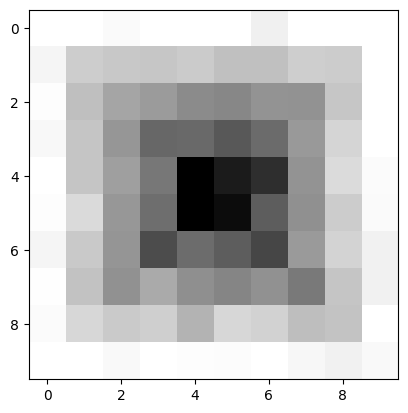

In [ ]:
# Add noise
image = np.array([
    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    [1.0, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.4, 0.4, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.0, 0.1, 0.2, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.0, 0.0, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.4, 0.4, 0.3, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.6, 0.6, 0.6, 0.6, 0.5, 0.8, 1.0],
    [1.0, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 1.0],
    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
], dtype=np.float32)

print(noise1)
image_noise1 = np.clip(image + noise1, 0, 1)

print(image_noise1)
plt.imshow(image_noise1, cmap='gray', vmin=0, vmax=1)
plt.show()

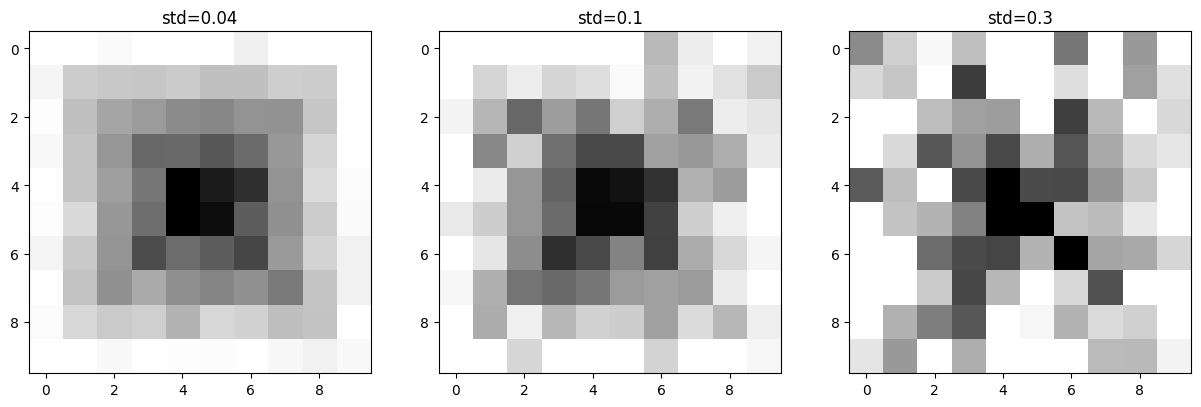

In [ ]:
image_noise2 = np.clip(image + noise2, 0, 1)
image_noise3 = np.clip(image + noise3, 0 ,1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image_noise1, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("std=0.04")
axes[1].imshow(image_noise2, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("std=0.1")
axes[2].imshow(image_noise3, cmap='gray', vmin=0, vmax=1)
axes[2].set_title("std=0.3")

plt.show()


##Gaussian Blur

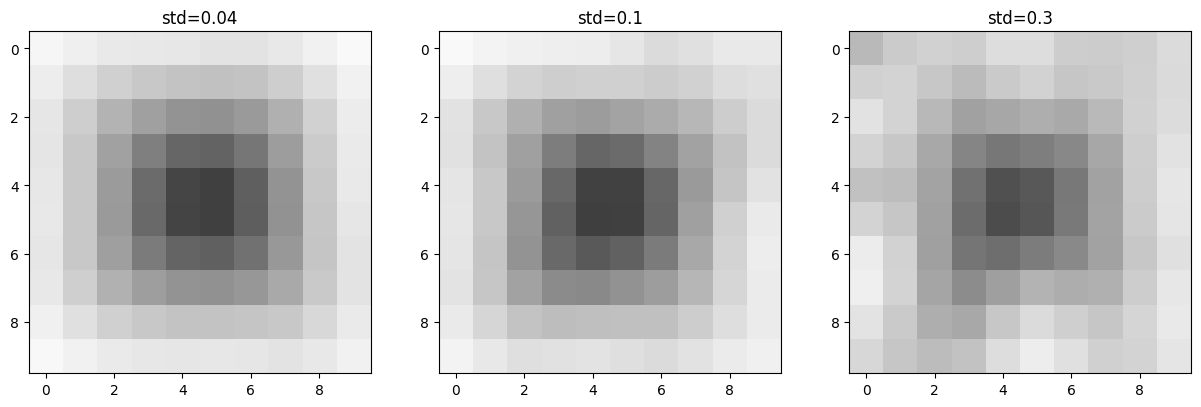

In [ ]:
from scipy.ndimage import gaussian_filter

image_noise1_denoised = gaussian_filter(image_noise1, sigma=1.0)
image_noise2_denoised = gaussian_filter(image_noise2, sigma=1.0)
image_noise3_denoised = gaussian_filter(image_noise3, sigma=1.0)

fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(image_noise1_denoised, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("std=0.04")
axes[1].imshow(image_noise2_denoised, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("std=0.1")
axes[2].imshow(image_noise3_denoised, cmap='gray', vmin=0, vmax=1)
axes[2].set_title("std=0.3")

plt.show()


##Median Filter

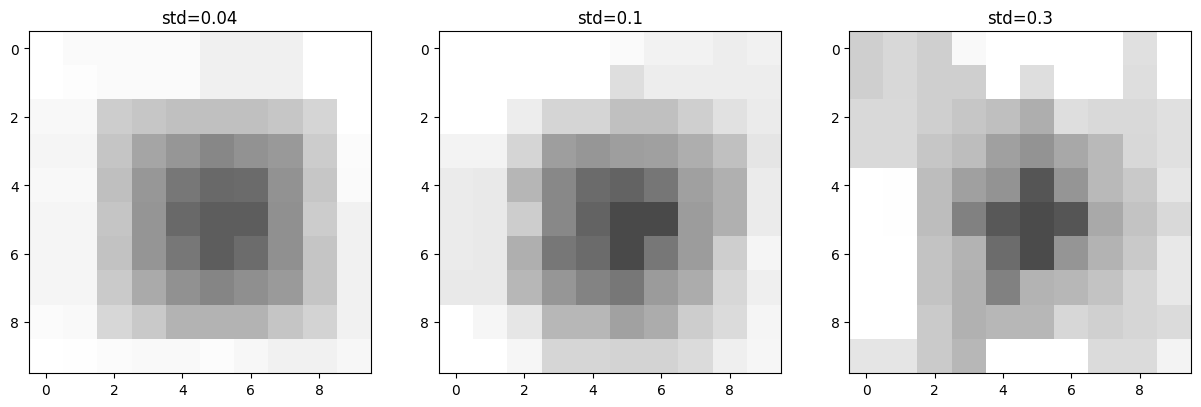

In [ ]:
from scipy.ndimage import median_filter

image_noise1_denoised = median_filter(image_noise1, size=4)
image_noise2_denoised = median_filter(image_noise2, size=4)
image_noise3_denoised = median_filter(image_noise3, size=4)

fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(image_noise1_denoised, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("std=0.04")
axes[1].imshow(image_noise2_denoised, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("std=0.1")
axes[2].imshow(image_noise3_denoised, cmap='gray', vmin=0, vmax=1)
axes[2].set_title("std=0.3")

plt.show()

##Non-Local Means Denoising

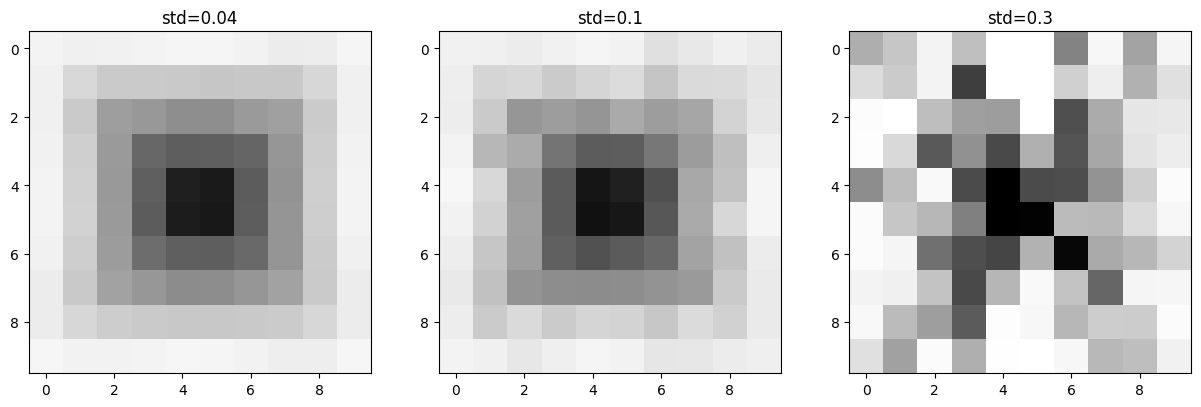

In [ ]:
#https://www.youtube.com/watch?v=Va4Rwoy1v88
from skimage.restoration import denoise_nl_means

image_noise1_denoised = denoise_nl_means(image_noise1, h=0.1, fast_mode=True)
image_noise2_denoised = denoise_nl_means(image_noise2, h=0.1, fast_mode=True)
image_noise3_denoised = denoise_nl_means(image_noise3, h=0.1, fast_mode=True)

fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(image_noise1_denoised, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("std=0.04")
axes[1].imshow(image_noise2_denoised, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("std=0.1")
axes[2].imshow(image_noise3_denoised, cmap='gray', vmin=0, vmax=1)
axes[2].set_title("std=0.3")

plt.show()

##Total Variation Denoising

In [ ]:
from skimage.restoration import denoise_nl_means

image_noise1_denoised = denoise_nl_means(image_noise1, h=0.1, fast_mode=True)
image_noise2_denoised = denoise_nl_means(image_noise2, h=0.1, fast_mode=True)
image_noise3_denoised = denoise_nl_means(image_noise3, h=0.1, fast_mode=True)

fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(image_noise1_denoised, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("std=0.04")
axes[1].imshow(image_noise2_denoised, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("std=0.1")
axes[2].imshow(image_noise3_denoised, cmap='gray', vmin=0, vmax=1)
axes[2].set_title("std=2.0")

plt.show()

#4D NP Tensors, & Dictionaries

## Defining, and Indexing 4D Tensors

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Create a batch of 10 synthetic images
images_4d = np.random.rand(2, 3, 4, 4)
print(f"Shape: {images_4d.shape}")
print(images_4d)
print(f"Number of images: {images_4d.shape[0]}")
print(f"Channels per image: {images_4d.shape[1]}")
print(f"Image dimensions: {images_4d.shape[2]} × {images_4d.shape[3]}")

Shape: (2, 3, 4, 4)
[[[[0.31730697 0.89089704 0.60135097 0.77897038]
   [0.49653861 0.81039646 0.41240873 0.84800414]
   [0.06171974 0.76620776 0.25531535 0.90397063]
   [0.98342053 0.43564538 0.27371989 0.6888092 ]]

  [[0.30615728 0.1200538  0.89692413 0.77095214]
   [0.59793021 0.31132291 0.42297761 0.36720028]
   [0.81401629 0.18166092 0.49119374 0.69899421]
   [0.15502262 0.61944222 0.20442561 0.29840582]]

  [[0.98227938 0.91032359 0.72961296 0.28077419]
   [0.10946646 0.59588815 0.84050154 0.44168427]
   [0.00940471 0.65608297 0.89216469 0.87866998]
   [0.00139254 0.78255952 0.68144055 0.09346258]]]


 [[[0.51532693 0.93116132 0.60090312 0.34388536]
   [0.56665244 0.55669061 0.30228626 0.91616903]
   [0.29994014 0.86538955 0.99268793 0.20909682]
   [0.65955164 0.16553185 0.36094792 0.94774215]]

  [[0.70703196 0.18397756 0.67484128 0.70524534]
   [0.18036338 0.09759695 0.15905948 0.45634593]
   [0.31648219 0.32194829 0.26363068 0.41472126]
   [0.88350956 0.56991603 0.54083866 0.

In [ ]:
# Access first image (returns 3D tensor)
first_image = images_4d[0]
print(f"First image shape: {first_image.shape}")  # Shape: (3, 4, 4)

# Access red channel of all images
all_red_channels = images_4d[:, 0, :, :]
#print(f"All red Channels:{all_red_channels}")
print(f"All red channels shape: {all_red_channels.shape}")  # Shape: (2, 4, 4)

# Access center pixel of all images, all channels
center_pixels = images_4d[:, :, 2, 2]
print(f"Center pixels shape: {center_pixels.shape}")  # Shape: (10, 3)
#print(f"Center pixel RGB values for first image: {center_pixels[0]}")


First image shape: (3, 4, 4)
All red channels shape: (2, 4, 4)
Center pixels shape: (2, 3)
First five images shape: (2, 3, 4, 4)


##Flattening and Reshaping Operations

Operation                      | Input Shape  | Output Shape | Use Case
-------------------------------|--------------|--------------|---------------------------
flatten()                      | (2,3,4,4)    | (96,)        | Complete vectorization
reshape(2, 3, -1)              | (2,3,4,4)    | (2,3,16)     | Flatten spatial only
reshape(2, -1)                 | (2,3,4,4)    | (2,48)       | One vector per image
reshape(-1, 4, 4)              | (2,3,4,4)    | (6,4,4)      | Stack all channels
reshape(2, -1, 4)              | (2,3,4,4)    | (2,12,4)     | Combine channels & rows

In [ ]:
#Define a new 4D Tensor
images_4d = np.array([
    [  # Image 0
        [  # Red channel
            [0, 0, 0, 0],
            [0, 1, 1, 0],
            [0, 1, 1, 0],
            [0, 0, 0, 0]
        ],
        [  # Green channel
            [0, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0]
        ],
        [  # Blue channel
            [0, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0]
        ]
    ],
    [  # Image 1
        [  # Red channel
            [0, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0]
        ],
        [  # Green channel
            [0, 0, 0, 0],
            [0, 0, 1, 0],
            [0, 1, 1, 0],
            [0, 0, 0, 0]
        ],
        [  # Blue channel
            [0, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0]
        ]
    ]
])
# Flatten entire 4D tensor to 1D
flat_complete = images_4d.flatten()
print(f"Original shape: {images_4d.shape}")      # (2, 3, 4, 4)
print(f"Flattened shape: {flat_complete.shape}") # (96,)
print(f"Total elements: {flat_complete.size}")   # 96 = 2×3×4×4

# Show first 20 elements
print(f"\nFirst 20 elements: {flat_complete[:20]}")
# These are from image 0, red channel, row by row

# Verify total sum
print(f"Sum of flattened array: {np.sum(flat_complete)}")  # Should be 7

Original shape: (2, 3, 4, 4)
Flattened shape: (96,)
Total elements: 96

First 20 elements: [0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0]
Sum of flattened array: 7


In [ ]:
# Flatten spatial dimensions, keep batch and channel structure
# MUST use reshape() because flatten() can't do selective flattening!
# The -1 means "calculate this dimension automatically"
# NumPy computes: total elements / (2 × 3) = 96 / 6 = 16

print()

images_flat_spatial = images_4d.reshape(2, 3, -1)
print(f"\nFlattened spatial dimensions: {images_flat_spatial.shape}")  # (2, 3, 16)

# Each image now has 3 channels of 16 pixels each
print(f"\nImage 0, red channel (flattened): {images_flat_spatial[0, 0]}")
# Should show: [0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0]
# This is the 4×4 red channel unwrapped row-by-row

print(f"\nImage 1, green channel (flattened): {images_flat_spatial[1, 1]}")
# Should show: [0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0]

print(f"\nImage 0, all channels (flattened):\n{images_flat_spatial[0]}")

print(f"\nMean of Image 0, per channel: {np.mean(images_flat_spatial[0], axis=1)}")

print(f"\nMean of Image 1, per channel: {np.mean(images_flat_spatial[1], axis=1)}")





Flattened spatial dimensions: (2, 3, 16)

Image 0, red channel (flattened): [0.31730697 0.89089704 0.60135097 0.77897038 0.49653861 0.81039646
 0.41240873 0.84800414 0.06171974 0.76620776 0.25531535 0.90397063
 0.98342053 0.43564538 0.27371989 0.6888092 ]

Image 1, green channel (flattened): [0.70703196 0.18397756 0.67484128 0.70524534 0.18036338 0.09759695
 0.15905948 0.45634593 0.31648219 0.32194829 0.26363068 0.41472126
 0.88350956 0.56991603 0.54083866 0.17706648]

Image 0, all channels (flattened):
[[0.31730697 0.89089704 0.60135097 0.77897038 0.49653861 0.81039646
  0.41240873 0.84800414 0.06171974 0.76620776 0.25531535 0.90397063
  0.98342053 0.43564538 0.27371989 0.6888092 ]
 [0.30615728 0.1200538  0.89692413 0.77095214 0.59793021 0.31132291
  0.42297761 0.36720028 0.81401629 0.18166092 0.49119374 0.69899421
  0.15502262 0.61944222 0.20442561 0.29840582]
 [0.98227938 0.91032359 0.72961296 0.28077419 0.10946646 0.59588815
  0.84050154 0.44168427 0.00940471 0.65608297 0.89216469

In [ ]:
# Flatten each image into a single vector
images_flat_per_image = images_4d.reshape(2, -1)
print(f"\nFlattened per image: {images_flat_per_image.shape}")  # (2, 48)
# Each of 2 images becomes a vector of 48 elements (3×4×4)

print(f"\nImage 0 flattened (first 24 elements):")
print(images_flat_per_image[0, :24])

print(f"\nImage 1 flattened (first 24 elements):")
print(images_flat_per_image[1, :24])

# This is useful for feeding to machine learning algorithms
print(f"\nSum per flattened image: {np.sum(images_flat_per_image, axis=1)}")
# Should be [4, 3] - matching our ones count


Flattened per image: (2, 48)

Image 0 flattened (first 24 elements):
[0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]

Image 1 flattened (first 24 elements):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]

Sum per flattened image: [4 3]


In [ ]:
# Combine all images into one larger "image"
batch_flat = images_4d.reshape(-1, 4, 4)
print(f"\nBatch flattened: {batch_flat.shape}")  # (6, 4, 4)
# Now we have 6 "layers" (2 images × 3 channels)

print(f"\nLayer 0 (Image 0, Red):\n{batch_flat[0]}")
print(f"\nLayer 1 (Image 0, Green):\n{batch_flat[1]}")
print(f"\nLayer 3 (Image 1, Red):\n{batch_flat[3]}")
print(f"\nLayer 4 (Image 1, Green):\n{batch_flat[4]}")


Batch flattened: (6, 4, 4)

Layer 0 (Image 0, Red):
[[0 0 0 0]
 [0 1 1 0]
 [0 1 1 0]
 [0 0 0 0]]

Layer 1 (Image 0, Green):
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]

Layer 3 (Image 1, Red):
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]

Layer 4 (Image 1, Green):
[[0 0 0 0]
 [0 0 1 0]
 [0 1 1 0]
 [0 0 0 0]]


##Statistical Operations with Tensors

Operation                          | Result Shape    | Interpretation
-----------------------------------|-----------------|----------------------------------
np.mean(images_4d, axis=0)         | (3, 4, 4)       | Average image across batch
np.mean(images_4d, axis=1)         | (2, 4, 4)       | Grayscale per image (channel avg)
np.mean(images_4d, axis=2)         | (2, 3, 4)       | Average along height (rows)
np.mean(images_4d, axis=3)         | (2, 3, 4)       | Average along width (columns)
np.mean(images_4d, axis=(2,3))     | (2, 3)          | Mean intensity per channel per image
np.mean(images_4d, axis=(1,2,3))   | (2,)            | Mean intensity per image (scalar)

In [ ]:
# Create a batch of 2 images manually (mostly zeros, some ones)
# Image 0: Has ones in red channel only
# Image 1: Has ones in green channel only
#See https://studentlaccd-my.sharepoint.com/:wb:/g/personal/sargsye2_laccd_edu/EeTuvrm4jplFrEc0QQc8lPcB3PNWSaApkIaf2-RUrd3zLw?e=U5PJv7
images_4d = np.array([
    [  # Image 0
        [  # Red channel
            [0, 0, 0, 0],
            [0, 1, 1, 0],
            [0, 1, 1, 0],
            [0, 0, 0, 0]
        ],
        [  # Green channel
            [1, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0]
        ],
        [  # Blue channel
            [1, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0]
        ]
    ],
    [  # Image 1
        [  # Red channel
            [4, 10, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0]
        ],
        [  # Green channel
            [5, 0, 0, 0],
            [0, 0, 1, 0],
            [0, 1, 1, 0],
            [0, 0, 0, 0]
        ],
        [  # Blue channel
            [0, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0]
        ]
    ]
])


# Average image across entire batch
mean_image = np.mean(images_4d, axis=0)  # Template/prototype image
print(f"The Mean Image:")
print(mean_image)
print(f"Mean image shape: {mean_image.shape}")  # (3, 4, 4)

#Mean Across Channels
mean_across_channels = np.mean(images_4d, axis=1)
print(mean_across_channels)
print(f"Mean Across Channels shape: {mean_across_channels.shape}")

#Mean Per Image Row
mean_per_image_row = np.mean(images_4d, axis=2)
print(mean_per_image_row)
print(f"Mean Across Channels shape: {mean_per_image_row.shape}")

# Standard deviation per channel across batch
std_per_channel = np.std(images_4d, axis=(0, 2, 3))
print(f"Std per channel shape: {std_per_channel.shape}")  # (3,)
print(f"Std per channel values: {std_per_channel}")

# Maximum intensity per image
max_per_image = np.max(images_4d, axis=(1, 2, 3))
print(f"Max per image shape: {max_per_image.shape}")  # (2,)
print(f"Max values: {max_per_image}")

# Minimum value in each channel of each image
min_per_channel_per_image = np.min(images_4d, axis=(2, 3))
print(f"Min per channel per image shape: {min_per_channel_per_image.shape}")  # (2, 3)
print(f"Min values:\n{min_per_channel_per_image}")

The Mean Image:
[[[2.  5.  0.  0. ]
  [0.  0.5 0.5 0. ]
  [0.  0.5 0.5 0. ]
  [0.  0.  0.  0. ]]

 [[3.  0.  0.  0. ]
  [0.  0.  0.5 0. ]
  [0.  0.5 0.5 0. ]
  [0.  0.  0.  0. ]]

 [[0.5 0.  0.  0. ]
  [0.  0.  0.  0. ]
  [0.  0.  0.  0. ]
  [0.  0.  0.  0. ]]]
Mean image shape: (3, 4, 4)
[[[0.66666667 0.         0.         0.        ]
  [0.         0.33333333 0.33333333 0.        ]
  [0.         0.33333333 0.33333333 0.        ]
  [0.         0.         0.         0.        ]]

 [[3.         3.33333333 0.         0.        ]
  [0.         0.         0.33333333 0.        ]
  [0.         0.33333333 0.33333333 0.        ]
  [0.         0.         0.         0.        ]]]
Mean Across Channels shape: (2, 4, 4)
[[[0.   0.5  0.5  0.  ]
  [0.25 0.   0.   0.  ]
  [0.25 0.   0.   0.  ]]

 [[1.   2.5  0.   0.  ]
  [1.25 0.25 0.5  0.  ]
  [0.   0.   0.   0.  ]]]
Mean Across Channels shape: (2, 3, 4)
Std per channel shape: (3,)
Std per channel values: [1.85299589 0.90947701 0.17399264]
Max per ima

###Dictionaries with 4D Tensors

Feature              | NumPy Array                | Python Dictionary
---------------------|----------------------------|----------------------------------
Access method        | Integer index: arr[0]      | String key: dict['key']
Structure            | Homogeneous elements       | Heterogeneous values
Ordering             | Ordered by position        | Key-based (unordered in <3.7)
Mathematical ops     | Vectorized operations      | Not directly supported
Purpose              | Numerical computation      | Data organization/labeling
Mutability           | Elements mutable           | Keys immutable, values mutable

In [ ]:
# Create labels for our image batch (0=normal, 1=abnormal)
labels = np.array([
    [   # Grayscale Image 0
        [0, 0, 0, 0],
        [0, 1, 1, 0],
        [0, 1, 1, 0],
        [0, 0, 0, 0]
    ],
    [   # Grayscale Image 1
        [0, 0, 0, 0],
        [0, 0, 1, 1],
        [0, 0, 1, 1],
        [0, 0, 0, 0]
    ]
])



# Store in dictionary
data = {
    'X': images_4d,      # Features: 4D tensor of images
    'y': labels,         # Labels: 1D array of classifications
    'n_samples': 2,      # Metadata: number of samples
    'image_size': 4      # Metadata: image dimensions
}

# Dictionary information
print(f"Dictionary keys: {data.keys()}")
print(f"Number of items: {len(data)}")
print(f"Images shape: {data['X'].shape}")
print(f"Labels shape: {data['y'].shape}")
print(f"Labels: \n{data['y']}")

print(data['X'][0,0,:])

Dictionary keys: dict_keys(['X', 'y', 'n_samples', 'image_size'])
Number of items: 4
Images shape: (2, 3, 4, 4)
Labels shape: (2, 4, 4)
Labels: 
[[[0 0 0 0]
  [0 1 1 0]
  [0 1 1 0]
  [0 0 0 0]]

 [[0 0 0 0]
  [0 0 1 1]
  [0 0 1 1]
  [0 0 0 0]]]
[[0 0 0 0]
 [0 1 1 0]
 [0 1 1 0]
 [0 0 0 0]]


#Thresholding

###Manual Threshold

In [ ]:
threshold_simple=0.5
binary_simple = (image < threshold_simple).astype(np.float32)
print(f"Threshold value: {threshold_simple}")
print(f"Logic: pixel < {threshold_simple} → nucleus (1), else → background (0)")
print(f"Nucleus pixels detected: {binary_simple.sum():.0f} out of {binary_simple.size}")
print(f"Percentage of image: {100 * binary_simple.sum() / binary_simple.size:.1f}%")
print(binary_simple)



Threshold value: 0.5
Logic: pixel < 0.5 → nucleus (1), else → background (0)
Nucleus pixels detected: 16 out of 100
Percentage of image: 16.0%
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


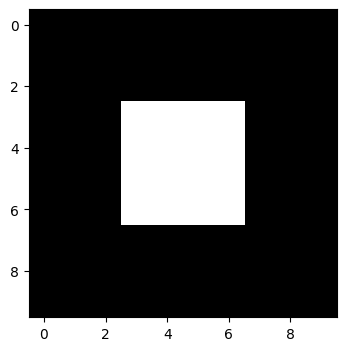

In [ ]:
# Visualize Manual Threshold
plt.figure(figsize=(4, 4))
plt.imshow(binary_simple, cmap='gray', interpolation='nearest')
#plt.title("Manual Threshold Result")
#plt.axis('off')
plt.show()

###Otsu's Automatic Threshold

[[255 255 255 255 255 255 255 255 255 255]
 [255 204 204 204 204 204 204 204 204 255]
 [255 204 153 153 153 153 153 153 204 255]
 [255 204 153 102 102 102 102 153 204 255]
 [255 204 153 102   0  25  51 153 204 255]
 [255 204 153 102   0   0 102 153 204 255]
 [255 204 153 102 102 102  76 153 204 255]
 [255 204 153 153 153 153 153 127 204 255]
 [255 204 204 204 204 204 204 204 204 255]
 [255 255 255 255 255 255 255 255 255 255]]
0.6
Otsu threshold (automatic): 0.600
Nucleus pixels detected: 17 out of 100
Percentage of image: 17.0%



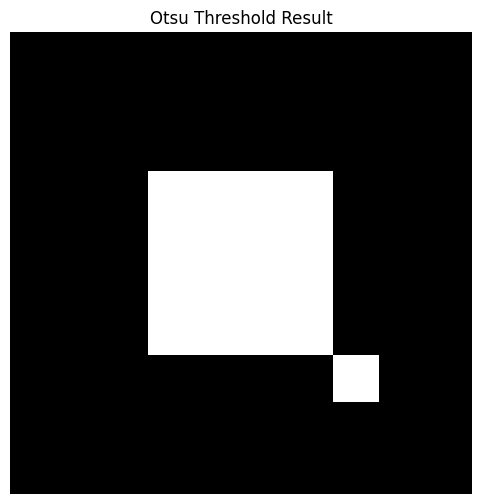

In [ ]:
# Otsu's method automatically finds optimal threshold
# How? Minimizes within-class variance (maximizes separation between classes)
# Assumes bimodal histogram (two peaks: dark nucleus, bright background)

# Convert to uint8 for Otsu (it expects integer values)
image_uint8 = (image * 255).astype(np.uint8)
print (image_uint8)

# Compute Otsu threshold
threshold_otsu = filters.threshold_otsu(image_uint8) / 255.0
print(threshold_otsu)

# Create binary mask
binary_otsu = (image < threshold_otsu).astype(np.float32)

print(f"Otsu threshold (automatic): {threshold_otsu:.3f}")
print(f"Nucleus pixels detected: {binary_otsu.sum():.0f} out of {binary_otsu.size}")
print(f"Percentage of image: {100 * binary_otsu.sum() / binary_otsu.size:.1f}%")
print()

# PROS: Automatic, adaptive to image content, optimal for bimodal histograms
# CONS: Assumes two classes, fails with complex histograms

# Visualize Otsu Result
plt.figure(figsize=(6, 6))
plt.imshow(binary_otsu, cmap='gray', interpolation='nearest')
plt.title("Otsu Threshold Result")
plt.axis('off')
plt.show()


#Morphological Operations

Morphological Operations Explained
Structuring Element (selem):
First, understand that morphology.disk(1) creates a small circular "stamp" or "brush" used for the operations. Think of it as a small disk pattern that moves across the image.

1. Erosion
Erosion shrinks white (foreground) regions. Imagine placing that small disk stamp on every part of the white region - if the stamp doesn't fit completely inside the white area, that pixel becomes black. It's like trimming the edges of white objects. Small white features disappear entirely. This is useful for removing noise or thin artifacts.
Example: A thin line of white pixels will vanish. A small isolated white dot will disappear.

2. Dilation
Dilation expands white (foreground) regions. The disk stamp grows the white area by adding white pixels around its borders. It's like fattening the white objects, making them bigger and thicker. Small gaps between white regions might get filled.
Example: A small black hole inside a white region might get filled. Separated objects get closer together.

3. Opening
Opening = Erosion THEN Dilation. You first shrink (erosion), then expand (dilation). This removes small white objects and noise while preserving the size and shape of larger objects. It's like cleaning up speckles while keeping the main structure intact.
Use case: Remove noise pixels from your image without damaging the main features.

4. Closing
Closing = Dilation THEN Erosion. You first expand (dilation), then shrink (erosion). This fills small black holes inside white regions while preserving the overall size. It's like smoothing out the interior of objects.
Use case: Fill gaps inside nuclei or cell regions that were accidentally segmented as holes.

In Your Project Context:
For nucleus segmentation:

Erosion: Remove small spurious dark pixels in cytoplasm
Dilation: Connect fragmented nucleus pieces
Opening: Clean up noise while keeping nucleus intact
Closing: Fill holes inside the nucleus region

[[1.  1.  1.  1.  1.  1.  1.  1.  1.  1. ]
 [1.  0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.5 1. ]
 [1.  0.8 0.6 0.6 0.6 0.6 0.6 0.6 0.8 1. ]
 [1.  0.8 0.6 0.4 0.4 0.4 0.4 0.6 0.8 1. ]
 [1.  0.8 0.6 0.4 1.  0.1 0.4 0.6 0.8 1. ]
 [1.  0.8 0.6 0.4 0.  0.  0.4 0.6 0.8 1. ]
 [1.  0.8 0.6 0.4 0.4 0.4 0.4 0.6 0.8 1. ]
 [1.  0.8 0.6 0.6 0.6 0.6 0.6 0.5 0.8 1. ]
 [1.  0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 1. ]
 [1.  1.  1.  1.  1.  1.  1.  1.  1.  1. ]]
[[255 255 255 255 255 255 255 255 255 255]
 [255 204 204 204 204 204 204 204 127 255]
 [255 204 153 153 153 153 153 153 204 255]
 [255 204 153 102 102 102 102 153 204 255]
 [255 204 153 102 255  25 102 153 204 255]
 [255 204 153 102   0   0 102 153 204 255]
 [255 204 153 102 102 102 102 153 204 255]
 [255 204 153 153 153 153 153 127 204 255]
 [255 204 204 204 204 204 204 204 204 255]
 [255 255 255 255 255 255 255 255 255 255]]
Erosion:  shrinks white regions
Dilation: expands white regions
Opening:  erosion then dilation (removes small objects)
Closing:  dilation

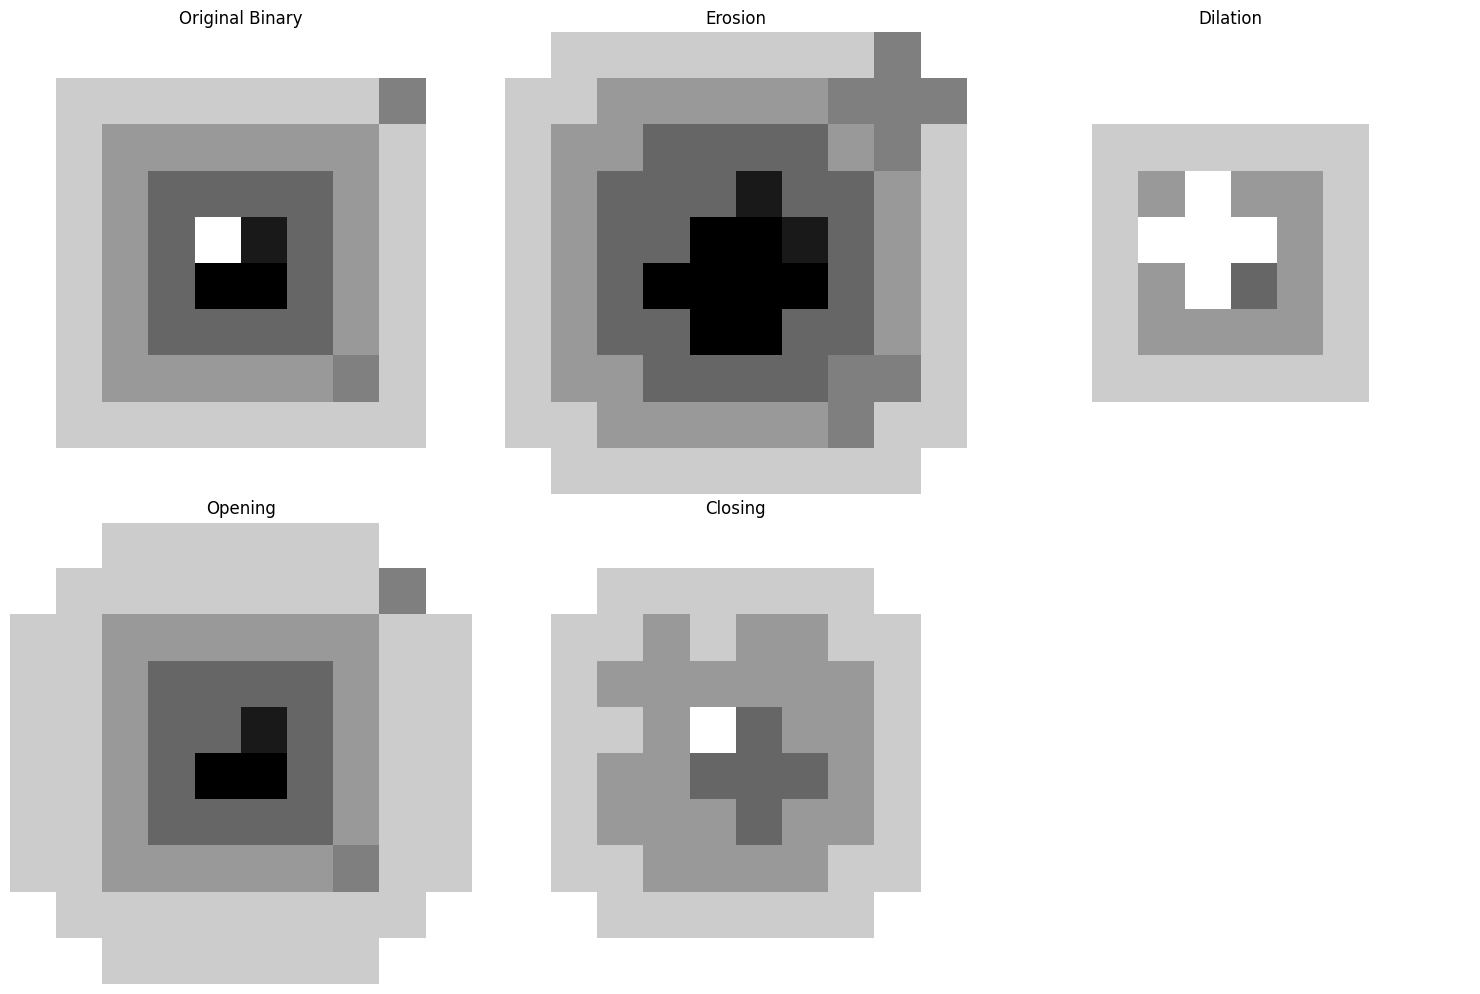

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import filters, morphology, exposure  # Add this line

image = np.array([
    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    [1.0, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, .5, 1.0],
    [1.0, 0.8, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.4, 0.4, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 1.0, 0.1, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.0, 0.0, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.4, 0.4, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.6, 0.6, 0.6, 0.6, 0.5, 0.8, 1.0],
    [1.0, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 1.0],
    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
], dtype=np.float32)


# Convert to binary uint8 for morphology
binary_uint8 = (image * 255).astype(np.uint8)
print(image)
print(binary_uint8)
# Morphological operations with small structuring element
selem = morphology.disk(1)

eroded = morphology.erosion(binary_uint8, selem)
dilated = morphology.dilation(binary_uint8, selem)
opened = morphology.opening(binary_uint8, selem)
closed = morphology.closing(binary_uint8, selem)

print("Erosion:  shrinks white regions")
print("Dilation: expands white regions")
print("Opening:  erosion then dilation (removes small objects)")
print("Closing:  dilation then erosion (fills small holes)")

# Convert back to float [0,1] for display
eroded = eroded.astype(np.float32) / 255.0
dilated = dilated.astype(np.float32) / 255.0
opened = opened.astype(np.float32) / 255.0
closed = closed.astype(np.float32) / 255.0

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(image, cmap='gray', interpolation='nearest', vmin=0, vmax=1)
axes[0, 0].set_title("Original Binary")
axes[0, 0].axis('off')

axes[0, 1].imshow(eroded, cmap='gray', interpolation='nearest', vmin=0, vmax=1)
axes[0, 1].set_title("Erosion")
axes[0, 1].axis('off')

axes[0, 2].imshow(dilated, cmap='gray', interpolation='nearest', vmin=0, vmax=1)
axes[0, 2].set_title("Dilation")
axes[0, 2].axis('off')

axes[1, 0].imshow(opened, cmap='gray', interpolation='nearest', vmin=0, vmax=1)
axes[1, 0].set_title("Opening")
axes[1, 0].axis('off')

axes[1, 1].imshow(closed, cmap='gray', interpolation='nearest', vmin=0, vmax=1)
axes[1, 1].set_title("Closing")
axes[1, 1].axis('off')

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


#RGB Images

RGB image shape: (10, 10, 3)
RGB image dtype: float32
RGB image range: [0.0, 1.0]


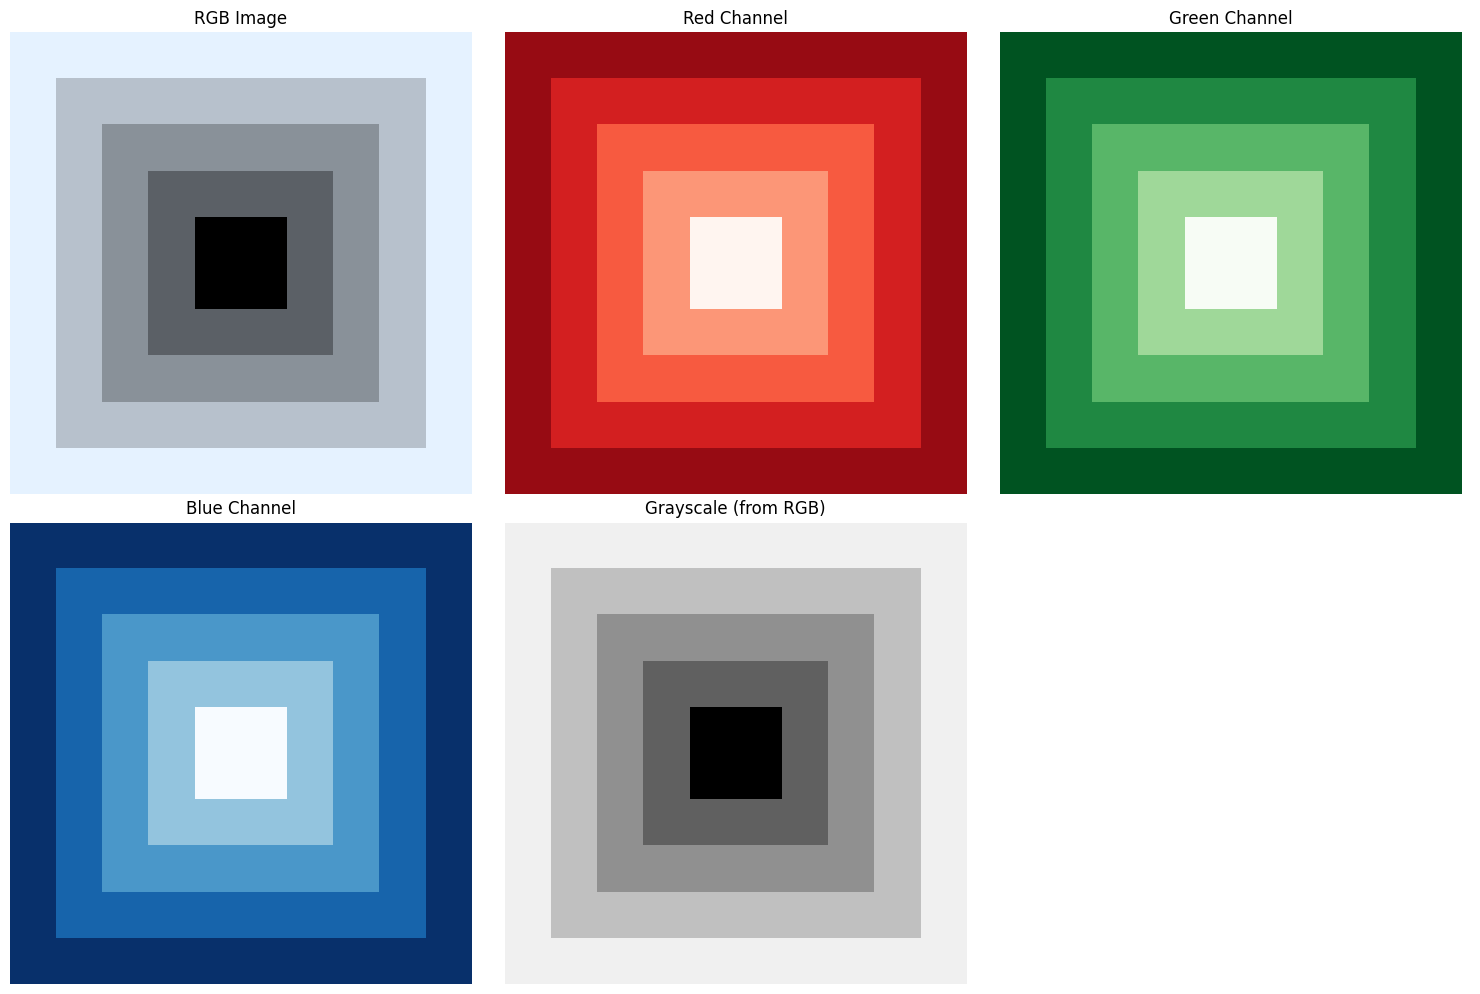

In [ ]:
# Create RGB version of cell image
rgb_image = np.zeros((10, 10, 3), dtype=np.float32)

# Use grayscale pattern with slight color tint
gray_pattern = np.array([
    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    [1.0, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.4, 0.4, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.0, 0.0, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.0, 0.0, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.4, 0.4, 0.4, 0.4, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.8, 1.0],
    [1.0, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 1.0],
    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
], dtype=np.float32)

rgb_image[:, :, 0] = gray_pattern * 0.9   # Red
rgb_image[:, :, 1] = gray_pattern * 0.95  # Green
rgb_image[:, :, 2] = gray_pattern * 1.0   # Blue (slight blue tint)

print(f"RGB image shape: {rgb_image.shape}")
print(f"RGB image dtype: {rgb_image.dtype}")
print(f"RGB image range: [{rgb_image.min()}, {rgb_image.max()}]")

# Extract channels
red_channel = rgb_image[:, :, 0]
green_channel = rgb_image[:, :, 1]
blue_channel = rgb_image[:, :, 2]

# Convert to grayscale using luminosity weights
gray_from_rgb = 0.299 * red_channel + 0.587 * green_channel + 0.114 * blue_channel

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(rgb_image, interpolation='nearest')
axes[0, 0].set_title("RGB Image")
axes[0, 0].axis('off')

axes[0, 1].imshow(red_channel, cmap='Reds', interpolation='nearest', vmin=0, vmax=1)
axes[0, 1].set_title("Red Channel")
axes[0, 1].axis('off')

axes[0, 2].imshow(green_channel, cmap='Greens', interpolation='nearest', vmin=0, vmax=1)
axes[0, 2].set_title("Green Channel")
axes[0, 2].axis('off')

axes[1, 0].imshow(blue_channel, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
axes[1, 0].set_title("Blue Channel")
axes[1, 0].axis('off')

axes[1, 1].imshow(gray_from_rgb, cmap='gray', interpolation='nearest', vmin=0, vmax=1)
axes[1, 1].set_title("Grayscale (from RGB)")
axes[1, 1].axis('off')

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


#Connected Component Analysis

In [7]:
from skimage.measure import regionprops
from scipy import ndimage
import numpy as np

binary = np.array([[1, 0, 1],
                   [1, 0, 1],
                   [0, 0, 0]])

# Use 4-connectivity (no diagonals)
labeled = ndimage.label(binary, structure=ndimage.generate_binary_structure(2, 1))[0]
print(labeled)
rp = regionprops(labeled)

print(len(rp))  # Now 2 regions
print(rp[0].bbox)  # (0, 0, 2, 1)
print(rp[1].bbox)  # (0, 2, 2, 3)

[[1 0 2]
 [1 0 2]
 [0 0 0]]
2
(0, 0, 2, 1)
(0, 2, 2, 3)


In [8]:
!git clone https://github.com/emilsar/Cedars.git
%cd Cedars/Project3
! python 1_prepdata.py
from skimage.io import imread
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from skimage.color import rgb2gray
from skimage.filters import sobel, scharr, apply_hysteresis_threshold, gaussian
from skimage.feature import canny
from skimage.measure import regionprops,regionprops_table
from skimage.morphology import binary_opening, disk, binary_closing, binary_dilation, binary_erosion
from skimage.draw import rectangle_perimeter
from scipy.ndimage import label as scilabel
import cv2
import matplotlib; matplotlib.rcParams['figure.dpi']=300
urothelial_cells=pd.read_pickle("urothelial_cell_toy_data.pkl")
images=np.transpose(urothelial_cells["X"].numpy()*255,(0,2,3,1)).astype(np.uint8)
labels=urothelial_cells["y"]


Cloning into 'Cedars'...
remote: Enumerating objects: 1261, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (170/170), done.
remote: Total 1261 (delta 109), reused 10 (delta 3), pack-reused 1088 (from 2)
Receiving objects: 100% (1261/1261), 1.22 GiB | 28.85 MiB/s, done.
Resolving deltas: 100% (486/486), done.
Updating files: 100% (896/896), done.
/content/Cedars/Project3/Cedars/Project3


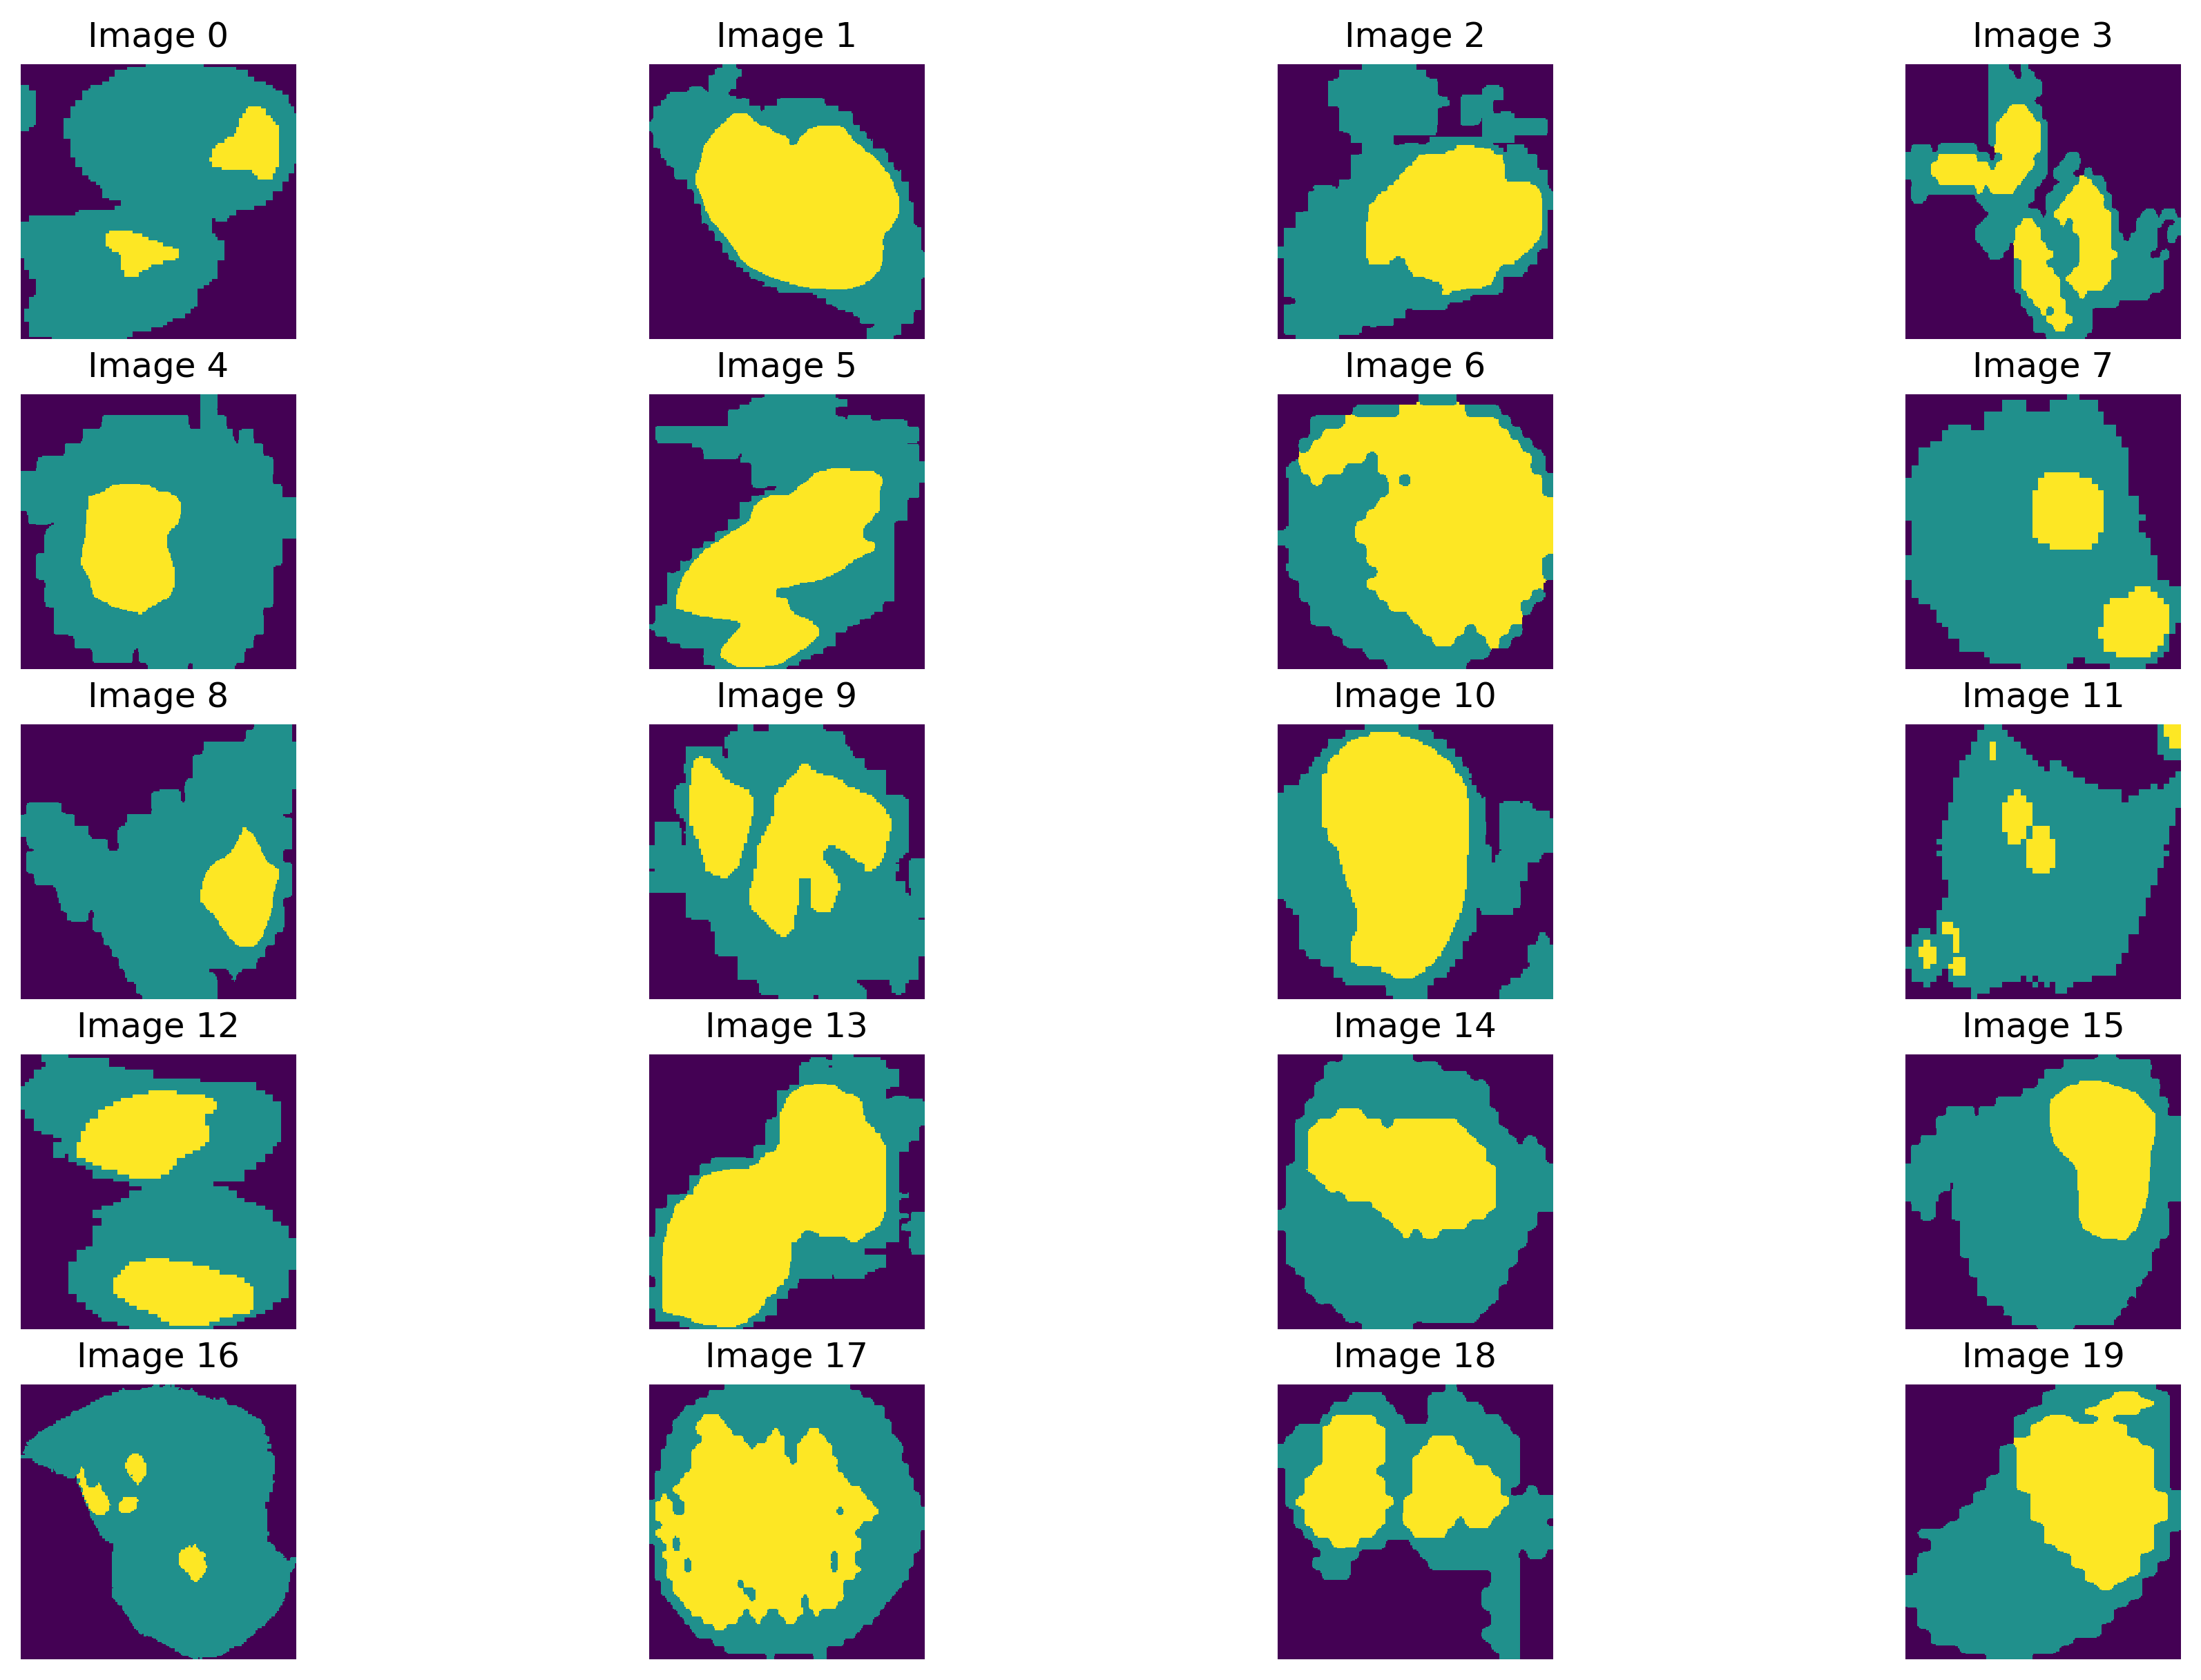

In [17]:
fig, axes = plt.subplots(5, 4, figsize=(15, 10))
k=0
for i in range(5):
  for j in range(4):
      axes[i, j].imshow(labels[k], cmap='viridis', interpolation='nearest')
      axes[i, j].set_title(f"Label {k}")
      axes[i, j].axis('off')
      k=k+1



In [28]:
# Labels in Image 7
print (np.unique(labels[7]))

[0 1 2]


In [27]:
from skimage.measure import regionprops
from scipy import ndimage

# Extract only nucleus pixels
nucleus_mask = (labels[7] == 2).astype(int)

# Label the separate nucleus regions
labeled_nuclei, num_nuclei = ndimage.label(nucleus_mask)

print(f"Number of nuclei found: {num_nuclei}")

# Now extract properties
rp = regionprops(labeled_nuclei)

for i, region in enumerate(rp):
    print(f"\nNucleus {i+1}:")
    print(f"  Area: {region.area} pixels")
    print(f"  Bounding box: {region.bbox}")
    print(f"  Perimeter: {region.perimeter}")
    print(f"  Centroid: {region.centroid}")

Number of nuclei found: 2

Nucleus 1:
  Area: 4194.0 pixels
  Bounding box: (73, 118, 145, 184)
  Perimeter: 266.72792206135784
  Centroid: (np.float64(109.03695755841679), np.float64(150.0267048164044))

Nucleus 2:
  Area: 3315.0 pixels
  Bounding box: (179, 179, 245, 245)
  Perimeter: 252.97056274847714
  Centroid: (np.float64(213.60150829562593), np.float64(212.84374057315233))


In [26]:
print(rp[0])

#The Full Pipeline

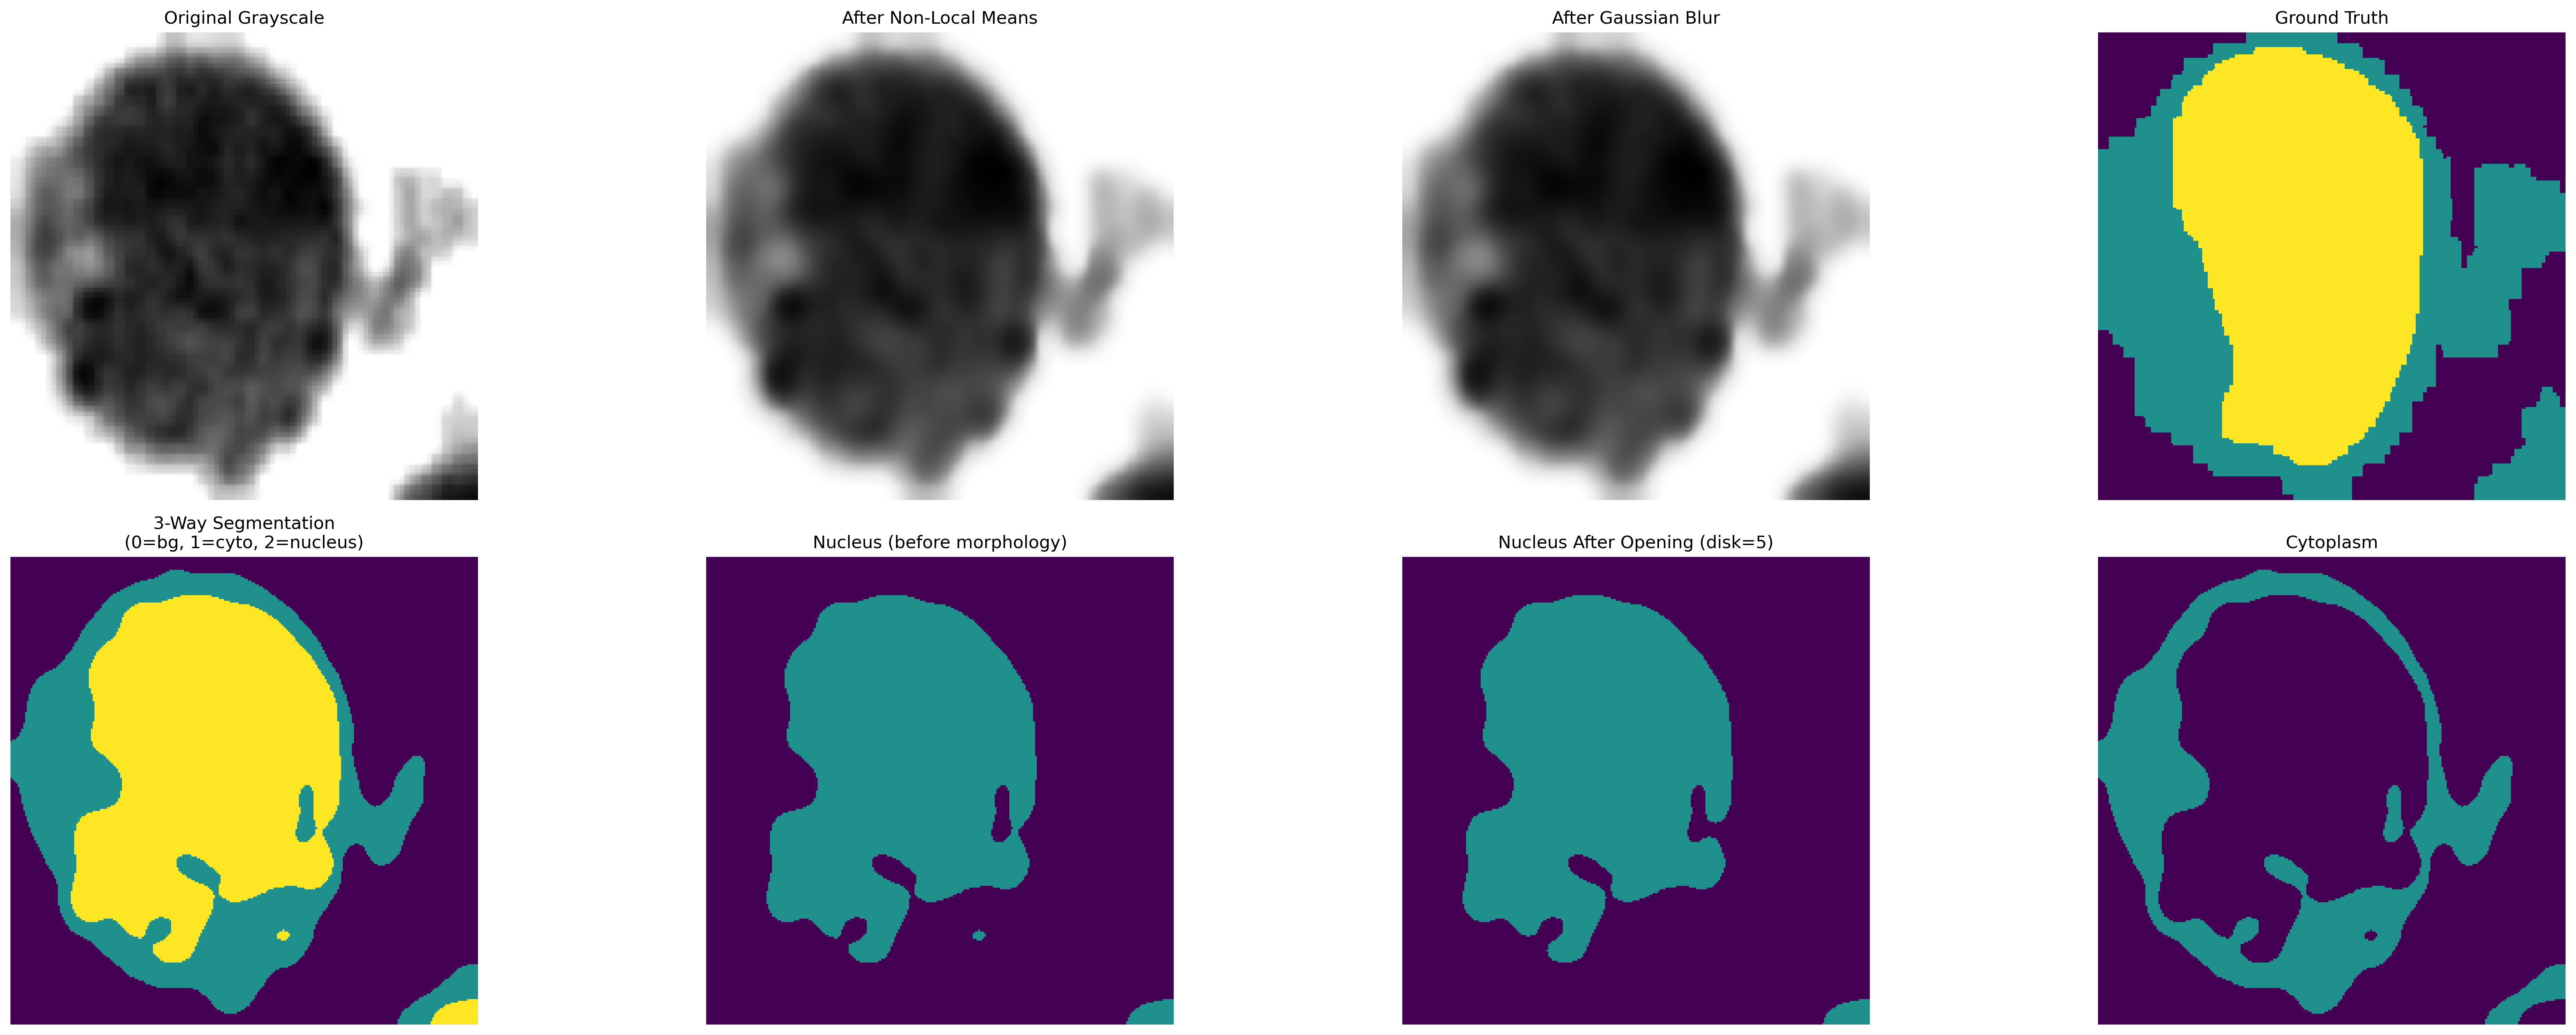

Ground Truth N/C Ratio:
  Nucleus area: 23981 pixels
  Cytoplasm area: 21489 pixels
  N/C ratio: 0.5274

Predicted N/C Ratio:
  Nucleus area: 21223 pixels
  Cytoplasm area: 14636 pixels
  N/C ratio: 0.5918

Difference: 0.0644
  Percentage error: 12.22%


In [66]:
from scipy.ndimage import gaussian_filter
from skimage.restoration import denoise_nl_means
from skimage.morphology import binary_opening, disk
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_number=10

# Get the image
img = images[image_number]

# Convert to grayscale
img_gray = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

# Non-local means denoising
img_denoised = denoise_nl_means(img_gray, h=0.2, fast_mode=True, patch_size=5, patch_distance=7)

# Gaussian Blur
img_blurred = gaussian_filter(img_denoised, sigma=1.0)

# Manually set intensity cutoffs
nucleus_max = 0.35
cytoplasm_min = 0.35
cytoplasm_max = 0.73

nucleus = (img_blurred < nucleus_max).astype(int)
cytoplasm = np.logical_and(img_blurred >= cytoplasm_min, img_blurred <= cytoplasm_max).astype(int)

# Morphological operations - use binary_opening with larger disk
nucleus_opened = binary_opening(nucleus, disk(5))

# Create 3-class segmentation for viridis display
segmented = np.zeros_like(img_blurred, dtype=int)
segmented[img_blurred < nucleus_max] = 2
segmented[(img_blurred >= cytoplasm_min) & (img_blurred <= cytoplasm_max)] = 1
segmented[img_blurred > cytoplasm_max] = 0

# Create figure
fig, axes = plt.subplots(2, 4, figsize=(28, 10))

axes[0,0].imshow(img_gray, cmap='gray')
axes[0,0].set_title("Original Grayscale")
axes[0,0].axis('off')

axes[0,1].imshow(img_denoised, cmap='gray')
axes[0, 1].set_title("After Non-Local Means")
axes[0, 1].axis('off')

axes[0, 2].imshow(img_blurred, cmap='gray')
axes[0, 2].set_title("After Gaussian Blur")
axes[0, 2].axis('off')

axes[0,3].imshow(labels[image_number], cmap='viridis')
axes[0,3].set_title("Ground Truth")
axes[0,3].axis('off')

axes[1, 0].imshow(segmented, cmap='viridis')
axes[1, 0].set_title(f"3-Way Segmentation\n(0=bg, 1=cyto, 2=nucleus)")
axes[1, 0].axis('off')

axes[1, 1].imshow(nucleus, cmap='viridis', vmin=0, vmax=2)
axes[1, 1].set_title("Nucleus (before morphology)")
axes[1, 1].axis('off')

axes[1, 2].imshow(nucleus_opened, cmap='viridis', vmin=0, vmax=2)
axes[1, 2].set_title("Nucleus After Opening (disk=5)")
axes[1, 2].axis('off')

axes[1, 3].imshow(cytoplasm, cmap='viridis', vmin=0, vmax=2)
axes[1, 3].set_title(f"Cytoplasm")
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

# Calculate N/C ratio
nucleus_area = nucleus_opened.sum()
cytoplasm_area = cytoplasm.sum()
nc_ratio_pred = nucleus_area / (nucleus_area + cytoplasm_area)

# Extract labels from ground truth
labels_img = labels[image_number]

# Get nucleus (label=2) and cytoplasm (label=1)
nucleus_true = (labels_img == 2).astype(int)
cytoplasm_true = (labels_img == 1).astype(int)

# Calculate true N/C ratio
nucleus_area_true = nucleus_true.sum()
cytoplasm_area_true = cytoplasm_true.sum()
nc_ratio_true = nucleus_area_true / (nucleus_area_true + cytoplasm_area_true)

print(f"Ground Truth N/C Ratio:")
print(f"  Nucleus area: {nucleus_area_true} pixels")
print(f"  Cytoplasm area: {cytoplasm_area_true} pixels")
print(f"  N/C ratio: {nc_ratio_true:.4f}")

# Also show the predicted ratio from earlier
print(f"\nPredicted N/C Ratio:")
print(f"  Nucleus area: {nucleus_area} pixels")
print(f"  Cytoplasm area: {cytoplasm_area} pixels")
print(f"  N/C ratio: {nc_ratio_pred:.4f}")

# Compare
print(f"\nDifference: {abs(nc_ratio_true - nc_ratio_pred):.4f}")
percentage_error = abs(nc_ratio_pred - nc_ratio_true) / nc_ratio_true * 100
print(f"  Percentage error: {percentage_error:.2f}%")